In [ ]:
import numpy as np
import pickle
import os
import time
import sys
from mlquantify.meta import QuaDapt

def MoSS_fixed(n, alpha, m):
    """
    Implementação corrigida do gerador de scores do MoSS.
    Binário: 1 = positivo, 0 = negativo.
    """
    import numpy as np

    n_pos = int(n * alpha)
    n_neg = n - n_pos
    merging_factor = m

    # Scores positivos
    p_score = np.random.uniform(size=n_pos) ** merging_factor

    # Scores negativos
    n_score = 1 - (np.random.uniform(size=n_neg) ** merging_factor)

    # Concatena
    scores = np.concatenate([
        np.stack([p_score, 1 - p_score, np.ones(n_pos)], axis=1),
        np.stack([n_score, 1 - n_score, np.zeros(n_neg)], axis=1),
    ])

    return scores

# aplica o monkey patch
QuaDapt.MoSS = MoSS_fixed

# path mlquantify vendorizado
root_path = os.path.abspath(os.path.join("..", "..", "third_party", "mlquantify_0.1.11"))
sys.path.insert(0, root_path)

OUTPUT_DIR = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def gerar_distribuicoes_moss(
    n_samples,
    n_prevalences,
    merges_array,
    n_curves,
    save_path
):
    """
    Gera um dicionário de distribuições sintéticas usando MoSS,
    salvando em pickle com log de tempo.
    """

    alphas = np.linspace(0.01, 0.99, n_prevalences)
    merges = merges_array

    synthetic_distributions = {}
    total = len(alphas) * len(merges)
    count = 0

    print(f"\n🚀 Gerando arquivo: {save_path}")
    print(f"Configuração:")
    print(f"  n_samples     = {n_samples:,}")
    print(f"  n_prevalences = {n_prevalences}")
    print(f"  n_merges      = {len(merges)}")
    print(f"  n_curves      = {n_curves}")
    print(f"  Total de combinações (alpha × merge): {total}\n")

    start_global = time.perf_counter()
    last_times = []

    for alpha in alphas:
        for merge in merges:
            start = time.perf_counter()

            curves = []
            for _ in range(n_curves):
                scores = QuaDapt.MoSS(n_samples, alpha, merge)

                syn_scores = np.concatenate([
                    scores[scores[:, 2] == 1][:, :2],
                    scores[scores[:, 2] == 0][:, :2]
                ])
                curves.append(syn_scores)

            synthetic_distributions[(round(alpha, 4), round(merge, 4))] = curves

            block_time = time.perf_counter() - start
            last_times.append(block_time)

            count += 1
            if count % 5 == 0 or count == total:
                avg = np.mean(last_times)
                remaining = (total - count) * avg
                print(
                    f"[{count}/{total}] "
                    f"Último bloco: {block_time:6.2f}s | "
                    f"Tempo médio/bloco: {avg:6.2f}s | "
                    f"Restante estimado: {remaining/60:6.1f} min"
                )

    with open(save_path, "wb") as f:
        pickle.dump(synthetic_distributions, f, protocol=pickle.HIGHEST_PROTOCOL)

    total_runtime = time.perf_counter() - start_global

    print("\n✔ Finalizado e salvo em:")
    print(f"  {save_path}")
    print(f"⏱ Tempo total: {total_runtime/60:,.2f} minutos\n")

    return synthetic_distributions


# =========================================================
#          CONFIGURAÇÕES PEDIDAS (6 ARQUIVOS)
# =========================================================

INTERVALOS = {
    "moss_35_65.pkl": (35, 65),
    "moss_40_60.pkl": (40, 60),
    "moss_45_55.pkl": (45, 55),
    "moss_50.pkl"   : (50, 50),
    }

N_SAMPLES     = 10_000
N_PREVALENCES = 40
N_MERGES      = 40
N_CURVES      = 100


if __name__ == "__main__":

    for filename, (lo, hi) in INTERVALOS.items():

        # gera merges entre lo% e hi%
        merges = np.linspace(lo/100, hi/100, N_MERGES)

        save_path = os.path.join(OUTPUT_DIR, filename)

        print("\n====================================")
        print(f" GERANDO ARQUIVO: {filename}")
        print(f" INTERVALO: {lo}% até {hi}%")
        print("====================================\n")

        gerar_distribuicoes_moss(
            n_samples=N_SAMPLES,
            n_prevalences=N_PREVALENCES,
            merges_array=merges,
            n_curves=N_CURVES,
            save_path=save_path
        )

    print("\n🏁 TODOS OS 6 ARQUIVOS FORAM GERADOS.\n")


 GERANDO ARQUIVO: moss_35_65.pkl
 INTERVALO: 35% até 65%


🚀 Gerando arquivo: /var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss/moss_35_65.pkl
Configuração:
  n_samples     = 10,000
  n_prevalences = 40
  n_merges      = 40
  n_curves      = 100
  Total de combinações (alpha × merge): 1600

[5/1600] Último bloco:   0.03s | Tempo médio/bloco:   0.03s | Restante estimado:    0.7 min
[10/1600] Último bloco:   0.03s | Tempo médio/bloco:   0.03s | Restante estimado:    0.7 min
[15/1600] Último bloco:   0.03s | Tempo médio/bloco:   0.03s | Restante estimado:    0.7 min
[20/1600] Último bloco:   0.03s | Tempo médio/bloco:   0.03s | Restante estimado:    0.7 min
[25/1600] Último bloco:   0.03s | Tempo médio/bloco:   0.03s | Restante estimado:    0.7 min
[30/1600] Último bloco:   0.03s | Tempo médio/bloco:   0.03s | Restante estimado:    0.7 min
[35/1600] Último bloco:   0.03s | Tempo médio/bloco:   0.03s | Restante estimado:    0.7 min
[40/1600] Último bloco:   0.03s | Tempo médio/b

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import warnings
from scipy.stats import skew, kurtosis, entropy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ============================================================
# ========== FEATURE EXTRACTION ==============================
# ============================================================

FEATURE_ORDER_BASE = ['mean','var','skew','kurt','q10','q25','q50','q75','q90','entropy']

def extract_features_base(scores):
    scores = np.ravel(scores)
    feats = {
        'mean': np.mean(scores),
        'var': np.var(scores),
        'skew': skew(scores),
        'kurt': kurtosis(scores),
        'q10': np.quantile(scores,0.1),
        'q25': np.quantile(scores,0.25),
        'q50': np.quantile(scores,0.5),
        'q75': np.quantile(scores,0.75),
        'q90': np.quantile(scores,0.9)
    }
    hist,_ = np.histogram(scores,bins=20,density=True)
    hist += 1e-12
    feats['entropy'] = entropy(hist)
    return np.array([feats[k] for k in FEATURE_ORDER_BASE])


# ============================================================
# ========== APP SAMPLING ====================================
# ============================================================

def generate_artificial_prevalences(n_prev=19,repeats=2):
    prevalences = np.linspace(0.05,0.95,n_prev)
    return [[1-p,p] for p in prevalences]*repeats

def sample_with_prevalence(y,prevalence,batch_size):
    pos_idx = np.where(y==1)[0]
    neg_idx = np.where(y==0)[0]
    n_pos = int(batch_size*prevalence[1])
    n_neg = batch_size - n_pos
    pos = np.random.choice(pos_idx,n_pos,replace=True)
    neg = np.random.choice(neg_idx,n_neg,replace=True)
    idx = np.concatenate([pos,neg])
    np.random.shuffle(idx)
    return idx

class APP:
    def __init__(self,batch_size=100,n_prev=19,repeats=2,seed=42):
        self.batch_size = batch_size
        self.prevalences = generate_artificial_prevalences(n_prev,repeats)
        np.random.seed(seed)
    def split(self,X,y):
        for prev in self.prevalences:
            idx = sample_with_prevalence(y,prev,self.batch_size)
            yield idx, prev


# ============================================================
# ========== DyS =============================================
# ============================================================

def hellinger_distance(p,q):
    p = p / (p.sum() + 1e-12)
    q = q / (q.sum() + 1e-12)
    return (1/np.sqrt(2)) * np.sqrt(np.sum((np.sqrt(p)-np.sqrt(q))**2))

def dys_quantifier(scores_batch,scores_train,y_train):
    pos_scores = scores_train[y_train==1]
    neg_scores = scores_train[y_train==0]
    h_batch,_ = np.histogram(scores_batch,bins=20,density=True)
    h_pos,_ = np.histogram(pos_scores,bins=20,density=True)
    h_neg,_ = np.histogram(neg_scores,bins=20,density=True)
    def mixture(prev):
        return (1-prev)*h_neg + prev*h_pos
    grid = np.linspace(0,1,1001)
    best_prev = min(grid,key=lambda p: hellinger_distance(h_batch,mixture(p)))
    return float(best_prev)


# ============================================================
# ========== TREINAR REGRESSOR MOSS ===========================
# ============================================================

def load_moss_regressor(pkl_path):
    with open(pkl_path,"rb") as f:
        synthetic_dists = pickle.load(f)
    Xf, Y = [], []
    for key,curves in synthetic_dists.items():
        all_scores = np.vstack(curves)[:,0]
        Xf.append(extract_features_base(all_scores))
        Y.append(key[0] if isinstance(key,tuple) else key)
    Xf = np.vstack(Xf)
    Y = np.array(Y)
    reg = RandomForestRegressor(n_estimators=300,random_state=42)
    reg.fit(Xf,Y)
    return reg


# ============================================================
# ========== CARREGAR DATASET CSV ============================
# ============================================================

def load_csv_dataset(path):
    df = pd.read_csv(path)
    if "y" in df.columns:
        y = df["y"].values
        X = df.drop(columns=["y"]).values
    else:
        y = df.iloc[:,-1].values
        X = df.iloc[:,:-1].values
    if len(np.unique(y))>2:
        y = (y==np.max(y)).astype(int)
    return X,y


# ============================================================
# ========== AVALIAR DATASET =================================
# ============================================================

def avaliar_dataset(ds_name, reg, app, root, pkl_name):
    path = os.path.join(root, ds_name)
    X,y = load_csv_dataset(path)
    X = StandardScaler().fit_transform(X)

    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.5,random_state=42,stratify=y)

    clf = RandomForestClassifier(n_estimators=300,random_state=42)
    clf.fit(Xtr,ytr)

    train_scores = clf.predict_proba(Xtr)[:,1]

    rows = []
    for idx,prev_real in app.split(Xte,yte):
        Xb = Xte[idx]
        yb = yte[idx]
        scores = clf.predict_proba(Xb)[:,1]

        prev_moss = reg.predict(extract_features_base(scores).reshape(1,-1))[0]
        prev_dys = dys_quantifier(scores, train_scores, ytr)

        rows.append({
            "arquivo_moss": pkl_name,
            "dataset": ds_name,
            "prevalencia_real": np.mean(yb),
            "prev_moss": prev_moss,
            "erro_moss": abs(prev_moss - np.mean(yb)),
            "erro_dys": abs(prev_dys - np.mean(yb)),
            "n_amostras": len(yb),
            "var_scores": np.var(scores),
            "entropy": extract_features_base(scores)[-1]
        })
    return rows


# ============================================================
# ========== LOOP GLOBAL =====================================
# ============================================================

moss_folder = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss"
datasets_root = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary"

pkls = [f for f in os.listdir(moss_folder) if f.endswith(".pkl")]
datasets = sorted([f for f in os.listdir(datasets_root) if f.endswith(".csv")])

app = APP(batch_size=100,n_prev=19,repeats=1,seed=42)
all_rows = []

for pkl_name in pkls:
    pkl_path = os.path.join(moss_folder, pkl_name)
    print(f"\nTreinando regressor MOSS com {pkl_name}")
    reg = load_moss_regressor(pkl_path)

    for ds in datasets:
        print(f"→ Dataset: {ds}")
        rows = avaliar_dataset(ds, reg, app, datasets_root, pkl_name)
        all_rows.extend(rows)

df = pd.DataFrame(all_rows)
df.to_csv("tabela_final_MOSS.csv", index=False)

print("\n✅ Tabela salva como tabela_final_MOSS.csv")


Treinando regressor MOSS com moss_5_95.pkl


→ Dataset: 1460_banana.csv
→ Dataset: 1462_banknote-authentication.csv
→ Dataset: 1466_cardiotocography.csv
→ Dataset: 1475_first-order-theorem-proving.csv
→ Dataset: 1479_hill-valley.csv
→ Dataset: 1485_madelon.csv
→ Dataset: 1489_phoneme.csv
→ Dataset: 1494_qsar-biodeg.csv
→ Dataset: 1496_ringnorm.csv
→ Dataset: 1497_wall-robot-navigation.csv
→ Dataset: 1504_steel-plates-fault.csv
→ Dataset: 1507_twonorm.csv
→ Dataset: 1526_wall-robot-navigation.csv
→ Dataset: 1535_volcanoes-b5.csv
→ Dataset: 1538_volcanoes-d1.csv
→ Dataset: 1539_volcanoes-d2.csv
→ Dataset: 1540_volcanoes-d3.csv
→ Dataset: 1541_volcanoes-d4.csv
→ Dataset: 1566_hill-valley.csv
→ Dataset: 182_satimage.csv
→ Dataset: 23_cmc.csv
→ Dataset: 28_optdigits.csv
→ Dataset: 294_satellite_image.csv
→ Dataset: 30_page-blocks.csv
→ Dataset: 312_scene.csv
→ Dataset: 375_JapaneseVowels.csv
→ Dataset: 40733_yeast.csv
→ Dataset: 44_spambase.csv
→ Dataset: 4538_GesturePhaseSegmentationProcessed.csv
→ Dataset: 60_waveform-5000.csv
→ Dat

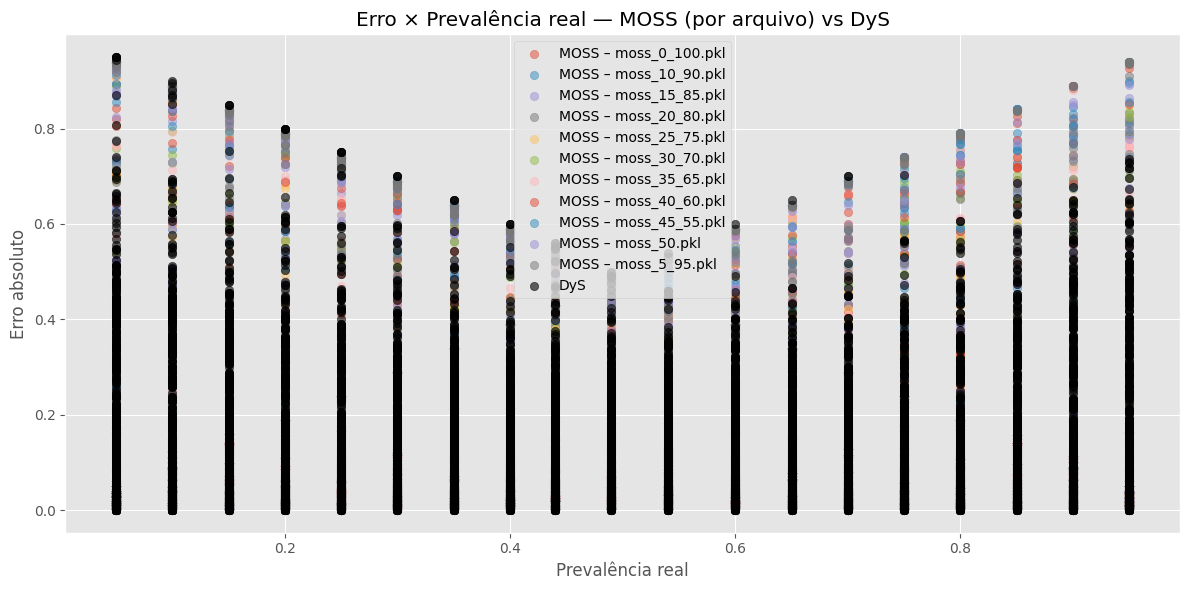

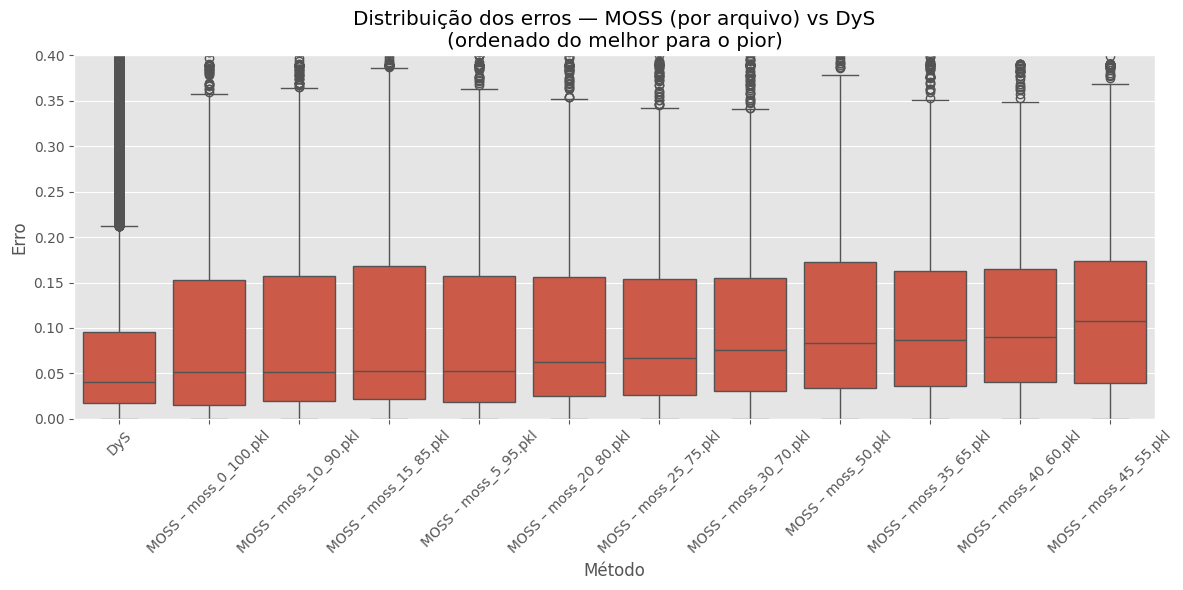

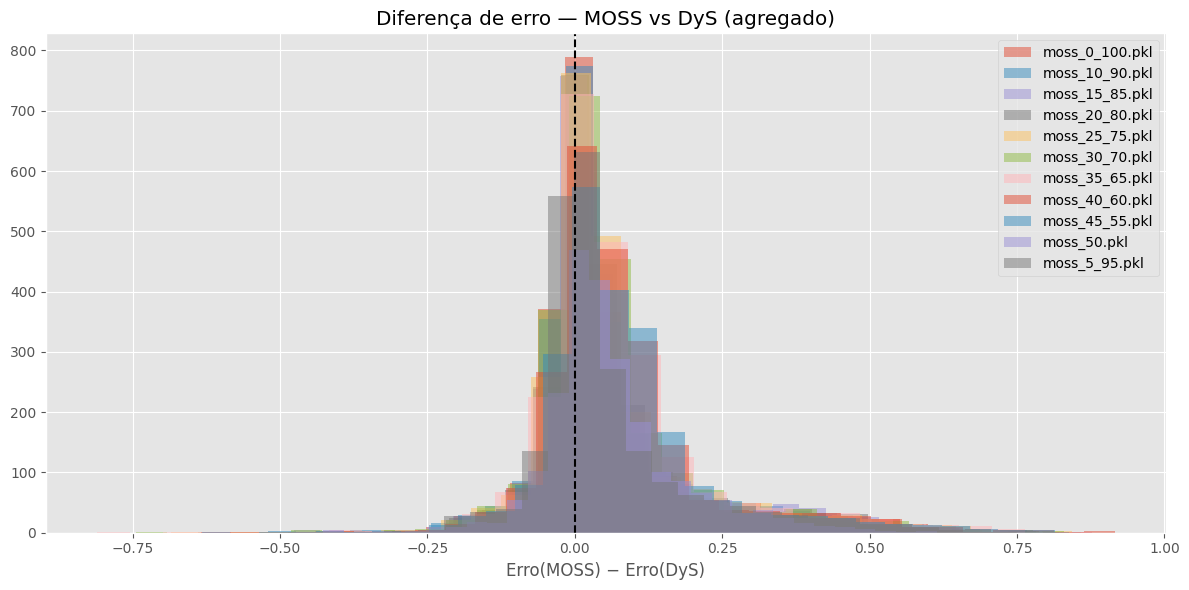

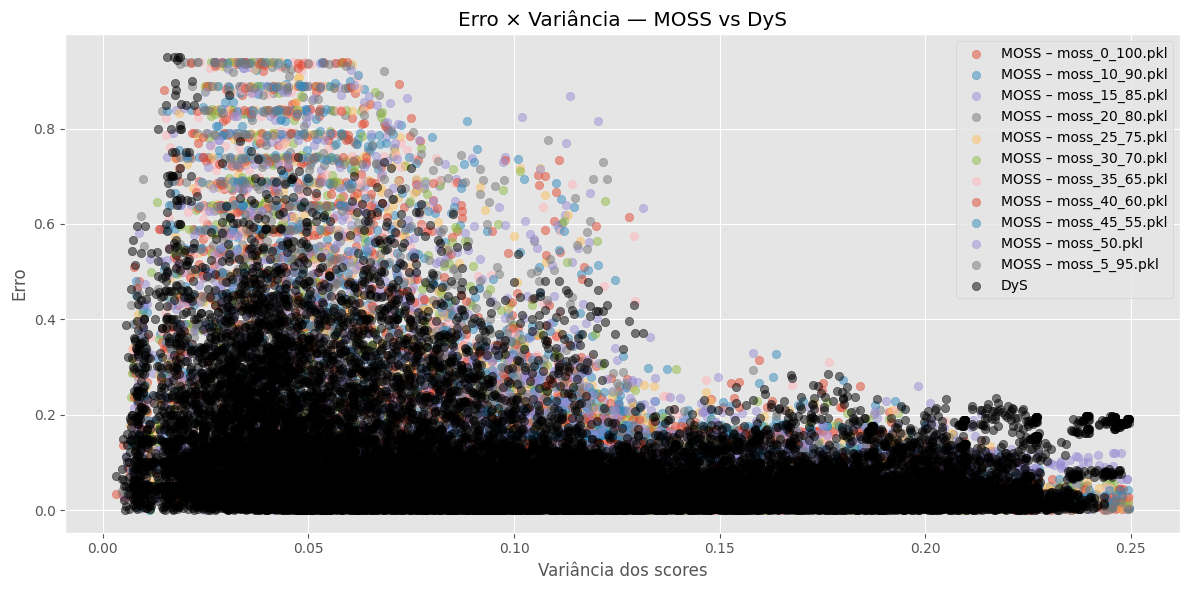

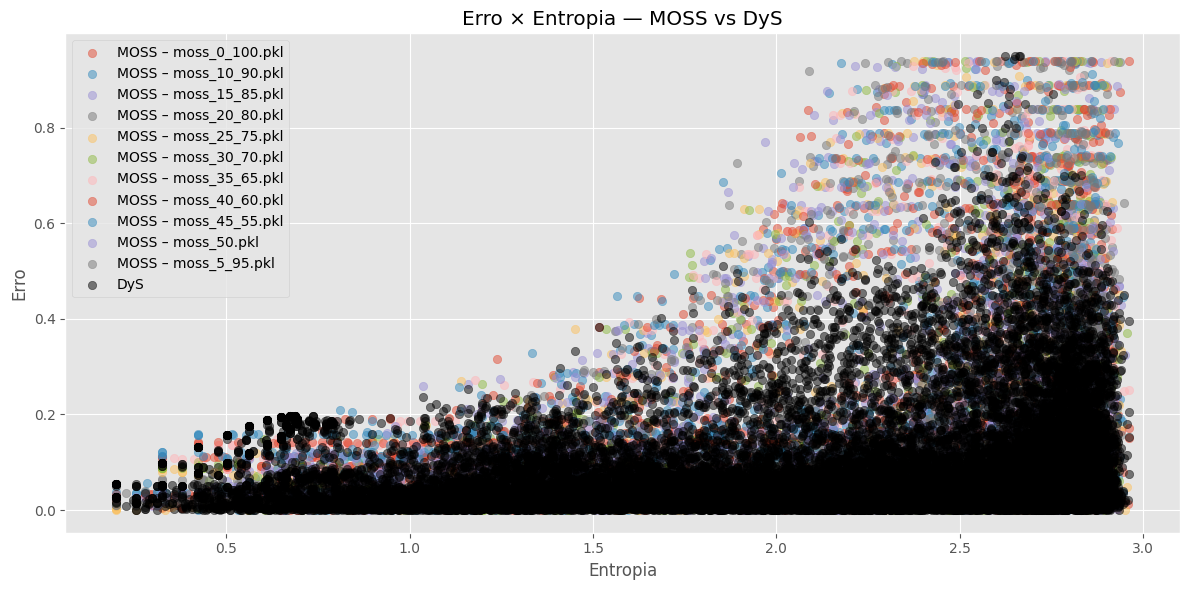

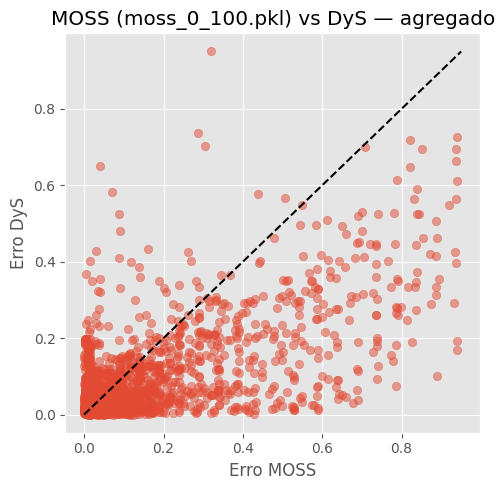

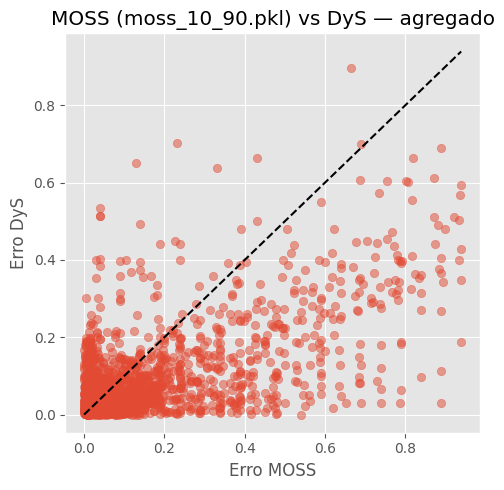

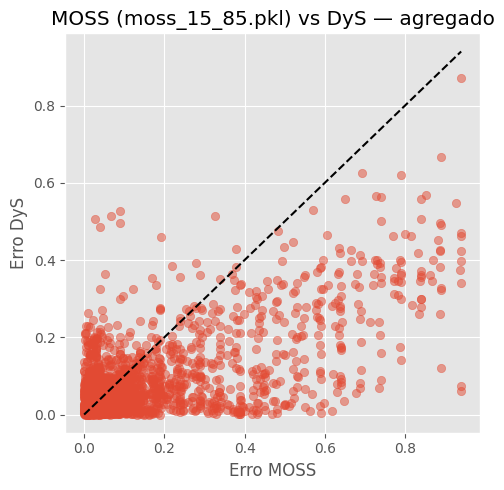

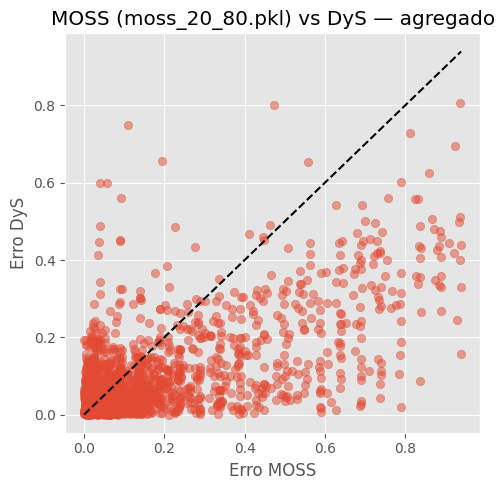

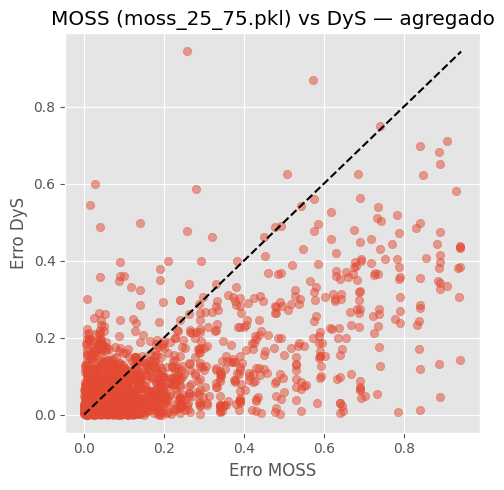

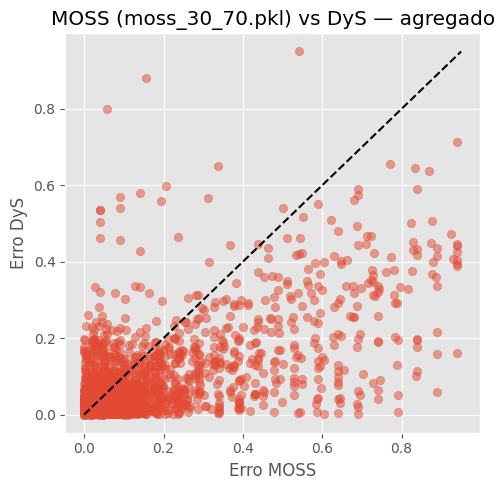

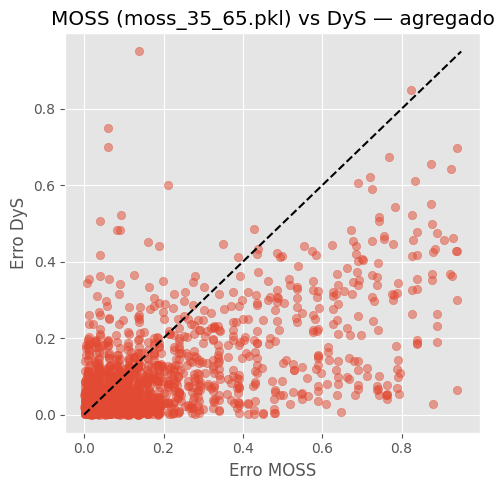

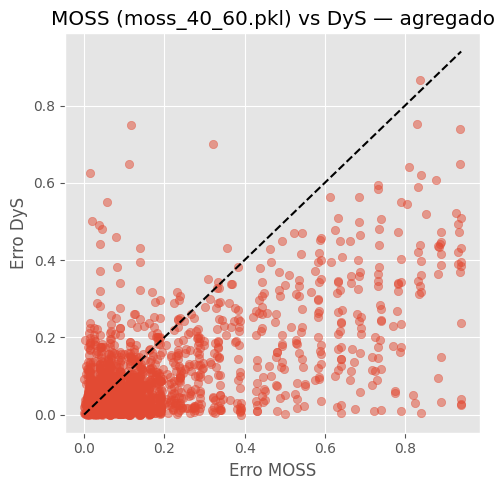

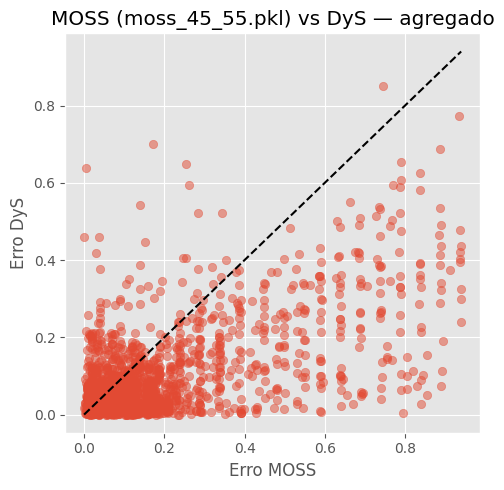

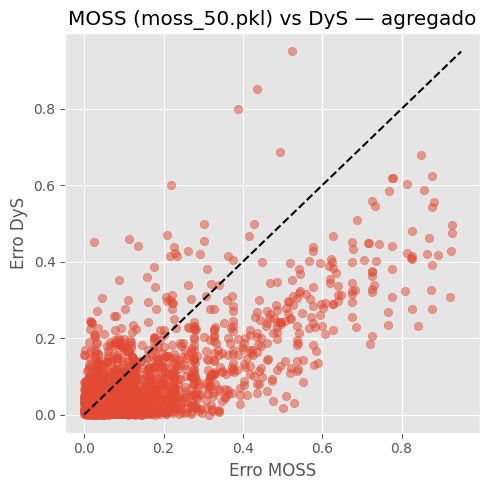

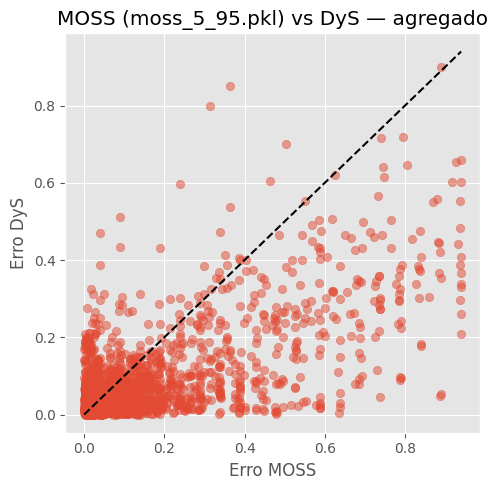

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("tabela_final_MOSS.csv")

arquivos_moss = sorted(df["arquivo_moss"].unique())

# =====================================================
# MONTAR LISTA DE MÉTODOS
# =====================================================
# Formato: (nome_legenda, coluna_do_erro, dataset, arquivo_moss)

metodos_expandidos = []

for ds in datasets:
    for moss in arquivos_moss:
        metodos_expandidos.append((
            f"{ds} – {moss}",
            "erro_moss",
            ds,
            moss
        ))

# DyS (um por dataset)
for ds in datasets:
    metodos_expandidos.append((
        f"{ds} – DyS",
        "erro_dys",
        ds,
        None
    ))

# =====================================================
# 1. ERRO × PREVALÊNCIA
# =====================================================

plt.figure(figsize=(12,6))

# MOSS (um por arquivo)
for moss in arquivos_moss:
    sub = df[df["arquivo_moss"] == moss]
    plt.scatter(
        sub["prevalencia_real"],
        sub["erro_moss"],
        label=f"MOSS – {moss}",
        alpha=0.5
    )

# DyS (global)
plt.scatter(
    df["prevalencia_real"],
    df["erro_dys"],
    label="DyS",
    color="black",
    alpha=0.6
)

plt.xlabel("Prevalência real")
plt.ylabel("Erro absoluto")
plt.title("Erro × Prevalência real — MOSS (por arquivo) vs DyS")
plt.legend()
plt.tight_layout()
plt.show()


# =====================================================
# 2. BOXPLOT DOS ERROS
# =====================================================


dfs = []

for moss in arquivos_moss:
    dfs.append(pd.DataFrame({
        "Método": f"MOSS – {moss}",
        "Erro": df[df["arquivo_moss"] == moss]["erro_moss"]
    }))

dfs.append(pd.DataFrame({
    "Método": "DyS",
    "Erro": df["erro_dys"]
}))

df_melt = pd.concat(dfs, ignore_index=True)

# calcular mediana do erro por método
ordem_metodos = (
    df_melt
    .groupby("Método")["Erro"]
    .median()
    .sort_values()          # menor erro = melhor
    .index
    .tolist()
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_melt,
    x="Método",
    y="Erro",
    order=ordem_metodos   # 👈 ordem explícita
)

plt.xticks(rotation=45)
plt.ylim(0, 0.4)          # 👈 eixo Y de 0 até 0.4
plt.title("Distribuição dos erros — MOSS (por arquivo) vs DyS\n(ordenado do melhor para o pior)")
plt.tight_layout()
plt.show()


# =====================================================
# 3. HISTOGRAMA — Diferença MOSS − DyS
# =====================================================

plt.figure(figsize=(12,6))

for moss in arquivos_moss:
    sub = df[df["arquivo_moss"] == moss]
    dif = sub["erro_moss"] - sub["erro_dys"]
    plt.hist(dif, bins=30, alpha=0.5, label=moss)

plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Erro(MOSS) − Erro(DyS)")
plt.title("Diferença de erro — MOSS vs DyS (agregado)")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 4. CORRELAÇÃO ERRO × VAR_SCORES
# =====================================================

plt.figure(figsize=(12,6))

for moss in arquivos_moss:
    sub = df[df["arquivo_moss"] == moss]
    plt.scatter(
        sub["var_scores"],
        sub["erro_moss"],
        alpha=0.5,
        label=f"MOSS – {moss}"
    )

plt.scatter(
    df["var_scores"],
    df["erro_dys"],
    color="black",
    alpha=0.5,
    label="DyS"
)

plt.xlabel("Variância dos scores")
plt.ylabel("Erro")
plt.title("Erro × Variância — MOSS vs DyS")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 5. CORRELAÇÃO ERRO × ENTROPIA
# =====================================================

plt.figure(figsize=(12,6))

for moss in arquivos_moss:
    sub = df[df["arquivo_moss"] == moss]
    plt.scatter(
        sub["entropy"],
        sub["erro_moss"],
        alpha=0.5,
        label=f"MOSS – {moss}"
    )

plt.scatter(
    df["entropy"],
    df["erro_dys"],
    color="black",
    alpha=0.5,
    label="DyS"
)

plt.xlabel("Entropia")
plt.ylabel("Erro")
plt.title("Erro × Entropia — MOSS vs DyS")
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================
# 6. COMPARAÇÃO DIRETA MOSS vs DyS (linha 45°)
# =====================================================

def scatter_45(x, y, title):
    plt.figure(figsize=(5,5))
    plt.scatter(x, y, alpha=0.5)
    lim = max(x.max(), y.max())
    plt.plot([0,lim], [0,lim], "k--")
    plt.xlabel("Erro MOSS")
    plt.ylabel("Erro DyS")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for moss in arquivos_moss:
    sub = df[df["arquivo_moss"] == moss]
    scatter_45(
        sub["erro_moss"],
        sub["erro_dys"],
        f"MOSS ({moss}) vs DyS — agregado"
    )


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import warnings
from scipy.stats import skew, kurtosis, entropy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from mlquantify.mixture import DyS
from mlquantify.meta import QuaDapt

warnings.filterwarnings("ignore")

# ============================================================
# ========== FEATURE EXTRACTION ==============================
# ============================================================

FEATURE_ORDER_BASE = ['mean','var','skew','kurt','q10','q25','q50','q75','q90','entropy']

def extract_features_base(scores):
    scores = np.ravel(scores)
    feats = {
        'mean': np.mean(scores),
        'var': np.var(scores),
        'skew': skew(scores),
        'kurt': kurtosis(scores),
        'q10': np.quantile(scores,0.1),
        'q25': np.quantile(scores,0.25),
        'q50': np.quantile(scores,0.5),
        'q75': np.quantile(scores,0.75),
        'q90': np.quantile(scores,0.9)
    }
    hist,_ = np.histogram(scores,bins=20,density=True)
    hist += 1e-12
    feats['entropy'] = entropy(hist)
    return np.array([feats[k] for k in FEATURE_ORDER_BASE])

# ============================================================
# ========== APP SAMPLING ====================================
# ============================================================

def generate_artificial_prevalences(n_prev=19,repeats=2):
    prevalences = np.linspace(0.05,0.95,n_prev)
    return [[1-p,p] for p in prevalences]*repeats

def sample_with_prevalence(y,prevalence,batch_size):
    pos_idx = np.where(y==1)[0]
    neg_idx = np.where(y==0)[0]
    n_pos = int(batch_size*prevalence[1])
    n_neg = batch_size - n_pos
    pos = np.random.choice(pos_idx,n_pos,replace=True)
    neg = np.random.choice(neg_idx,n_neg,replace=True)
    idx = np.concatenate([pos,neg])
    np.random.shuffle(idx)
    return idx

class APP:
    def __init__(self,batch_size=100,n_prev=19,repeats=2,seed=42):
        self.batch_size = batch_size
        self.prevalences = generate_artificial_prevalences(n_prev,repeats)
        np.random.seed(seed)
    def split(self,X,y):
        for prev in self.prevalences:
            idx = sample_with_prevalence(y,prev,self.batch_size)
            yield idx, prev


# ============================================================
# ========== DyS =============================================
# ============================================================

def hellinger_distance(p,q):
    p = p / (p.sum() + 1e-12)
    q = q / (q.sum() + 1e-12)
    return (1/np.sqrt(2)) * np.sqrt(np.sum((np.sqrt(p)-np.sqrt(q))**2))

def dys_quantifier(scores_batch,scores_train,y_train):
    pos_scores = scores_train[y_train==1]
    neg_scores = scores_train[y_train==0]
    h_batch,_ = np.histogram(scores_batch,bins=20,density=True)
    h_pos,_ = np.histogram(pos_scores,bins=20,density=True)
    h_neg,_ = np.histogram(neg_scores,bins=20,density=True)
    def mixture(prev):
        return (1-prev)*h_neg + prev*h_pos
    grid = np.linspace(0,1,1001)
    best_prev = min(grid,key=lambda p: hellinger_distance(h_batch,mixture(p)))
    return float(best_prev)


# ============================================================
# ========== TREINAR REGRESSOR MOSS ===========================
# ============================================================

def load_moss_regressor(pkl_path):
    with open(pkl_path,"rb") as f:
        synthetic_dists = pickle.load(f)
    Xf, Y = [], []
    for key,curves in synthetic_dists.items():
        all_scores = np.vstack(curves)[:,0]
        Xf.append(extract_features_base(all_scores))
        Y.append(key[0] if isinstance(key,tuple) else key)
    Xf = np.vstack(Xf)
    Y = np.array(Y)
    reg = RandomForestRegressor(n_estimators=300,random_state=42)
    reg.fit(Xf,Y)
    return reg


# ============================================================
# ========== CARREGAR DATASET CSV ============================
# ============================================================

def load_csv_dataset(path):
    df = pd.read_csv(path)
    if "y" in df.columns:
        y = df["y"].values
        X = df.drop(columns=["y"]).values
    else:
        y = df.iloc[:,-1].values
        X = df.iloc[:,:-1].values
    if len(np.unique(y))>2:
        y = (y==np.max(y)).astype(int)
    return X,y


# ============================================================
# ========== AVALIAR DATASET =================================
# ============================================================

def avaliar_dataset_dyssyn(ds_name, app, root):
    path = os.path.join(root, ds_name)
    X, y = load_csv_dataset(path)
    X = StandardScaler().fit_transform(X)

    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.5, random_state=42, stratify=y
    )

    # =========================
    # Classificador base
    # =========================
    clf = RandomForestClassifier(n_estimators=300, random_state=42)

    # =========================
    # DyS + QuaDapt (DySSyn)
    # =========================
    dys = DyS(
        learner=clf,
        measure="topsoe"
    )

    dyssyn = QuaDapt(
        quantifier=dys,
        merging_factors=[0.1, 0.3, 0.5, 0.7, 0.9],
        measure="topsoe"
    )

    # Fit no conjunto de treino
    dyssyn.fit(Xtr, ytr)

    rows = []

    for idx, prev_real in app.split(Xte, yte):
        Xb = Xte[idx]
        yb = yte[idx]

        prev_pred = dyssyn.predict(Xb)[1]  # classe positiva

        rows.append({
            "dataset": ds_name,
            "prevalencia_real": np.mean(yb),
            "prev_dyssyn": prev_pred,
            "erro_dyssyn": abs(prev_pred - np.mean(yb)),
            "n_amostras": len(yb)
        })

    return rows

# ============================================================
# ========== LOOP GLOBAL =====================================
# ============================================================

moss_folder = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/moss"
datasets_root = "/var/new_homes/julio/mestrado/mestrado-dyssyn/datasets/binary"
datasets = sorted([f for f in os.listdir(datasets_root) if f.endswith(".csv")])

app = APP(batch_size=100, n_prev=19, repeats=1, seed=42)

all_rows = []

for ds in datasets:
    print(f"→ Dataset: {ds}")
    rows = avaliar_dataset_dyssyn(ds, app, datasets_root)
    all_rows.extend(rows)

df = pd.DataFrame(all_rows)
df.to_csv("tabela_final_DySSyn.csv", index=False)

print("\n✅ Tabela salva como tabela_final_DySSyn.csv")

→ Dataset: 1460_banana.csv
→ Dataset: 1462_banknote-authentication.csv
→ Dataset: 1466_cardiotocography.csv
→ Dataset: 1475_first-order-theorem-proving.csv
→ Dataset: 1479_hill-valley.csv
→ Dataset: 1485_madelon.csv
→ Dataset: 1489_phoneme.csv
→ Dataset: 1494_qsar-biodeg.csv
→ Dataset: 1496_ringnorm.csv
→ Dataset: 1497_wall-robot-navigation.csv
→ Dataset: 1504_steel-plates-fault.csv
→ Dataset: 1507_twonorm.csv
→ Dataset: 1526_wall-robot-navigation.csv
→ Dataset: 1535_volcanoes-b5.csv
→ Dataset: 1538_volcanoes-d1.csv
→ Dataset: 1539_volcanoes-d2.csv
→ Dataset: 1540_volcanoes-d3.csv
→ Dataset: 1541_volcanoes-d4.csv
→ Dataset: 1566_hill-valley.csv
→ Dataset: 182_satimage.csv
→ Dataset: 23_cmc.csv
→ Dataset: 28_optdigits.csv
→ Dataset: 294_satellite_image.csv
→ Dataset: 30_page-blocks.csv
→ Dataset: 312_scene.csv
→ Dataset: 375_JapaneseVowels.csv
→ Dataset: 40733_yeast.csv
→ Dataset: 44_spambase.csv
→ Dataset: 4538_GesturePhaseSegmentationProcessed.csv
→ Dataset: 60_waveform-5000.csv
→ Dat

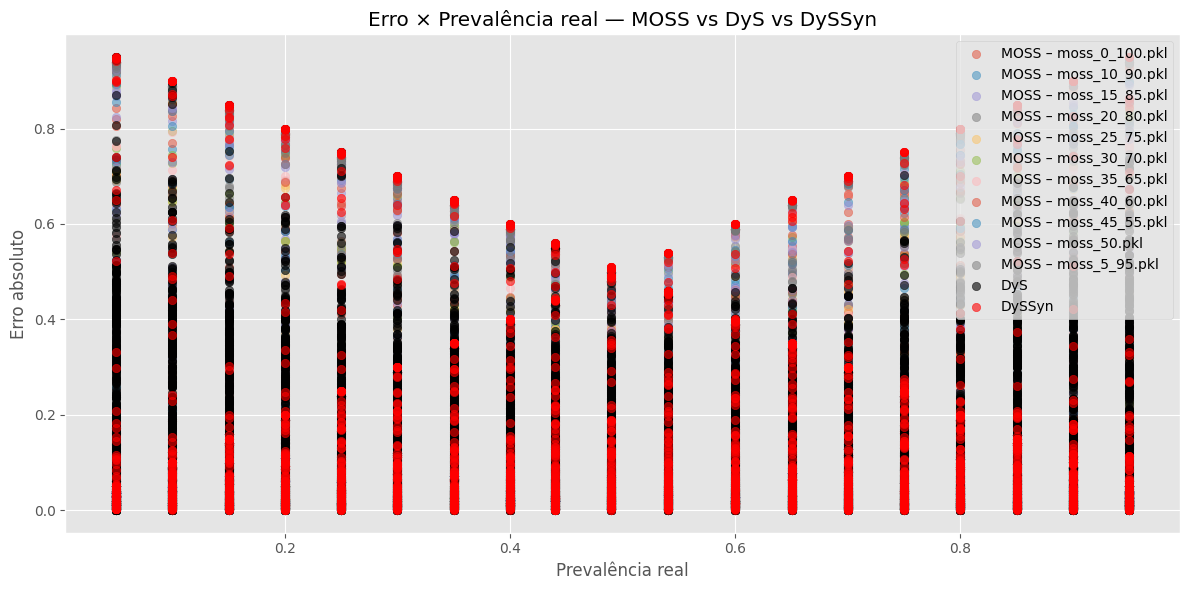

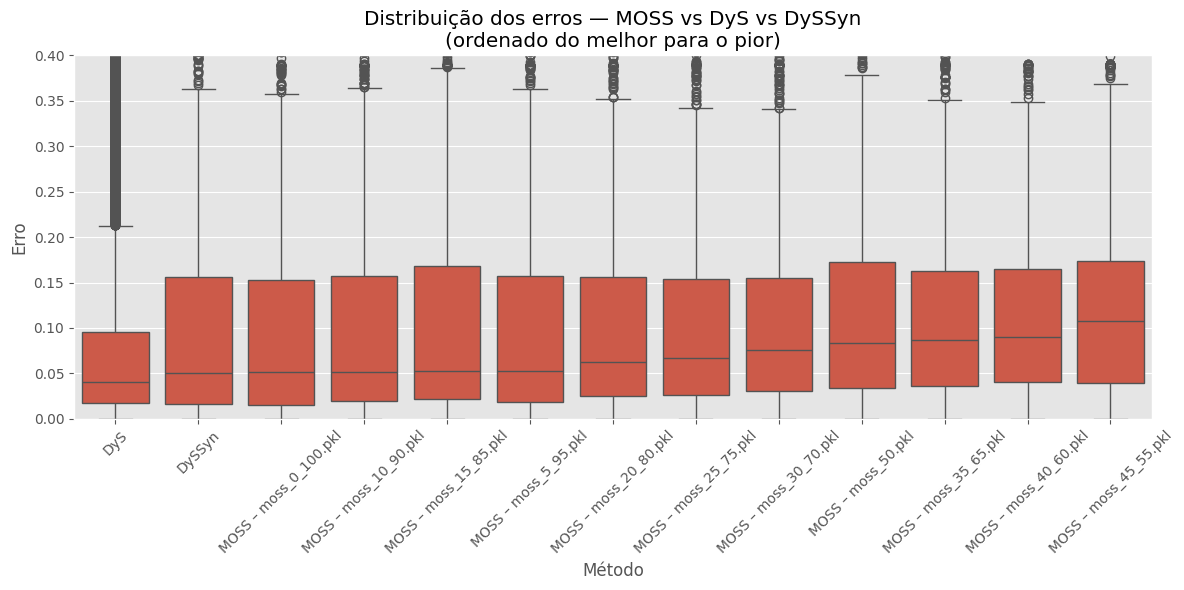

In [ ]:
plt.figure(figsize=(12,6))

# MOSS (um por arquivo)
for moss in arquivos_moss:
    sub = df[df["arquivo_moss"] == moss]
    plt.scatter(
        sub["prevalencia_real"],
        sub["erro_moss"],
        label=f"MOSS – {moss}",
        alpha=0.5
    )

# DyS
plt.scatter(
    df["prevalencia_real"],
    df["erro_dys"],
    label="DyS",
    color="black",
    alpha=0.6
)

# DySSyn
plt.scatter(
    df["prevalencia_real"],
    df["erro_dyssyn"],
    label="DySSyn",
    color="red",
    alpha=0.6
)

plt.xlabel("Prevalência real")
plt.ylabel("Erro absoluto")
plt.title("Erro × Prevalência real — MOSS vs DyS vs DySSyn")
plt.legend()
plt.tight_layout()
plt.show()

dfs = []

# MOSS
for moss in arquivos_moss:
    dfs.append(pd.DataFrame({
        "Método": f"MOSS – {moss}",
        "Erro": df[df["arquivo_moss"] == moss]["erro_moss"]
    }))

# DyS
dfs.append(pd.DataFrame({
    "Método": "DyS",
    "Erro": df["erro_dys"]
}))

# DySSyn
dfs.append(pd.DataFrame({
    "Método": "DySSyn",
    "Erro": df["erro_dyssyn"]
}))

df_melt = pd.concat(dfs, ignore_index=True)

# ordenar do melhor para o pior (menor mediana)
ordem_metodos = (
    df_melt
    .groupby("Método")["Erro"]
    .median()
    .sort_values()
    .index
    .tolist()
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_melt,
    x="Método",
    y="Erro",
    order=ordem_metodos
)

plt.xticks(rotation=45)
plt.ylim(0, 0.4)
plt.title(
    "Distribuição dos erros — MOSS vs DyS vs DySSyn\n"
    "(ordenado do melhor para o pior)"
)
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import plotly.express as px

# carregar dados
df = pd.read_csv("tabela_final_MOSS.csv")

# escolher qual MOSS usar
MOSS_ESCOLHIDO = "moss_0_100.pkl"

# DyS
df_dys = (
    df
    .groupby("dataset", as_index=False)
    .agg({"erro_dys": "mean"})
)
df_dys["Método"] = "DyS"
df_dys = df_dys.rename(columns={"erro_dys": "Erro"})

# DySSyn
df_dyssyn = (
    df
    .groupby("dataset", as_index=False)
    .agg({"erro_dyssyn": "mean"})
)
df_dyssyn["Método"] = "DySSyn"
df_dyssyn = df_dyssyn.rename(columns={"erro_dyssyn": "Erro"})

# MOSS
df_moss = (
    df[df["arquivo_moss"] == MOSS_ESCOLHIDO]
    .groupby("dataset", as_index=False)
    .agg({"erro_moss": "mean"})
)
df_moss["Método"] = "MOSS 0–100"
df_moss = df_moss.rename(columns={"erro_moss": "Erro"})

# juntar tudo
df_long = pd.concat(
    [df_moss, df_dys, df_dyssyn],
    ignore_index=True
)

# plot
fig = px.line(
    df_long,
    x="dataset",
    y="Erro",
    color="Método",
    markers=True,
    title="Erro médio por dataset — MOSS 0–100 vs DyS vs DySSyn",
)

fig.update_layout(
    xaxis_title="Dataset",
    yaxis_title="Erro absoluto médio",
    legend_title="Método",
    hovermode="x unified"
)

fig.update_xaxes(tickangle=45)

# 💾 salvar em HTML
fig.write_html("erro_medio_por_dataset_MOSS_DyS_DySSyn.html")

# opcional: mostrar na tela
fig.show()

In [10]:
import pandas as pd

# carregar dados
df = pd.read_csv("tabela_final_MOSS.csv")

MOSS_ESCOLHIDO = "moss_0_100.pkl"

# erro médio por dataset
df_agg = (
    df
    .groupby("dataset", as_index=False)
    .agg({
        "erro_dys": "mean",
        "erro_dyssyn": "mean"
    })
)

df_moss = (
    df[df["arquivo_moss"] == MOSS_ESCOLHIDO]
    .groupby("dataset", as_index=False)
    .agg({"erro_moss": "mean"})
)

# juntar tudo numa tabela só
df_cmp = (
    df_agg
    .merge(df_moss, on="dataset", how="inner")
)

# determinar vencedor por dataset
def vencedor(row):
    erros = {
        "MOSS 0–100": row["erro_moss"],
        "DyS": row["erro_dys"],
        "DySSyn": row["erro_dyssyn"]
    }
    return min(erros, key=erros.get)

df_cmp["Vencedor"] = df_cmp.apply(vencedor, axis=1)

# flag: MOSS melhor que os dois
df_cmp["MOSS_vence_ambos"] = (
    (df_cmp["erro_moss"] < df_cmp["erro_dys"]) &
    (df_cmp["erro_moss"] < df_cmp["erro_dyssyn"])
)

# resumo de vitórias
resumo_vitorias = (
    df_cmp["Vencedor"]
    .value_counts()
    .rename("N_datasets")
    .reset_index()
    .rename(columns={"index": "Método"})
)

# métrica chave
n_moss_vence_ambos = df_cmp["MOSS_vence_ambos"].sum()
total_datasets = df_cmp.shape[0]

print("=== VITÓRIAS POR MÉTODO ===")
print(resumo_vitorias)

print("\n=== MOSS vence DyS e DySSyn simultaneamente ===")
print(f"{n_moss_vence_ambos} / {total_datasets} datasets "
      f"({100 * n_moss_vence_ambos / total_datasets:.1f}%)")


=== VITÓRIAS POR MÉTODO ===
     Vencedor  N_datasets
0         DyS          84
1      DySSyn          20
2  MOSS 0–100          15

=== MOSS vence DyS e DySSyn simultaneamente ===
15 / 119 datasets (12.6%)
